<a href="https://colab.research.google.com/github/Anurag-snippet/ML_assignment/blob/main/ML_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#                                                                      TASK 1

In [7]:
#PROBLEM 1

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import random
import os

# seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# versions
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

# GPU check
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU available:", gpus)
else:
    print("\nNo GPU detected")
    # CPU slower → less parallelism; GPU → faster via parallel computation

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

No GPU detected


In [4]:
#PROBLEM 2

import tensorflow as tf
import numpy as np

# load datasets
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# (a) shapes
print("MNIST train:", mnist_x_train.shape, mnist_y_train.shape)
print("MNIST test:", mnist_x_test.shape, mnist_y_test.shape)

print("CIFAR-10 train:", cifar_x_train.shape, cifar_y_train.shape)
print("CIFAR-10 test:", cifar_x_test.shape, cifar_y_test.shape)

# (b) dtype and range
print("\nMNIST dtype:", mnist_x_train.dtype, "range:", mnist_x_train.min(), "-", mnist_x_train.max())
print("CIFAR dtype:", cifar_x_train.dtype, "range:", cifar_x_train.min(), "-", cifar_x_train.max())

# (c) class counts MNIST
counts = np.bincount(mnist_y_train)
print("\nMNIST class counts:", counts)

MNIST train: (60000, 28, 28) (60000,)
MNIST test: (10000, 28, 28) (10000,)
CIFAR-10 train: (50000, 32, 32, 3) (50000, 1)
CIFAR-10 test: (10000, 32, 32, 3) (10000, 1)

MNIST dtype: uint8 range: 0 - 255
CIFAR dtype: uint8 range: 0 - 255

MNIST class counts: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


/tmp/ipykernel_24215/3250977653.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(cifar_classes[int(cifar_y_train[idx])])


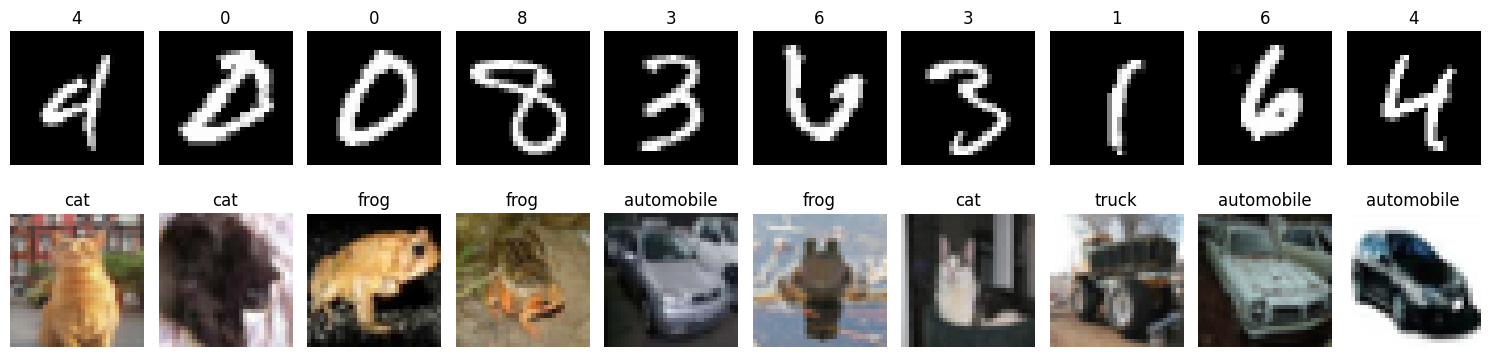

In [8]:
import matplotlib.pyplot as plt

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,4))

# MNIST row
for i in range(10):
    idx = np.random.randint(0, len(mnist_x_train))
    plt.subplot(2,10,i+1)
    plt.imshow(mnist_x_train[idx], cmap='gray')
    plt.title(mnist_y_train[idx])
    plt.axis('off')

# CIFAR row
for i in range(10):
    idx = np.random.randint(0, len(cifar_x_train))
    plt.subplot(2,10,10+i+1)
    plt.imshow(cifar_x_train[idx])
    plt.title(cifar_classes[int(cifar_y_train[idx])])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [11]:
# PROBLEM 3

import tensorflow as tf
import numpy as np

# load MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

def preprocess(x, y):
    print("Before:")
    print("shape:", x.shape, "dtype:", x.dtype, "range:", x.min(), "-", x.max())
    print("label sample:", y[:5])

    # (a) normalize
    x = x.astype(np.float32) / 255.0
    print("\nAfter normalization:")
    print("dtype:", x.dtype, "range:", x.min(), "-", x.max())

    # (b) reshape
    if len(x.shape) == 3:
        x = x.reshape(-1, 28, 28, 1)
    print("\nAfter reshape:")
    print("shape:", x.shape)

    # (c) one-hot
    y = tf.keras.utils.to_categorical(y, 10)
    print("\nAfter one-hot:")
    print("shape:", y.shape)
    print("label sample:", y[:5])

    return x, y

x_train, y_train = preprocess(x_train, y_train)

Before:
shape: (60000, 28, 28) dtype: uint8 range: 0 - 255
label sample: [5 0 4 1 9]

After normalization:
dtype: float32 range: 0.0 - 1.0

After reshape:
shape: (60000, 28, 28, 1)

After one-hot:
shape: (60000, 10)
label sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


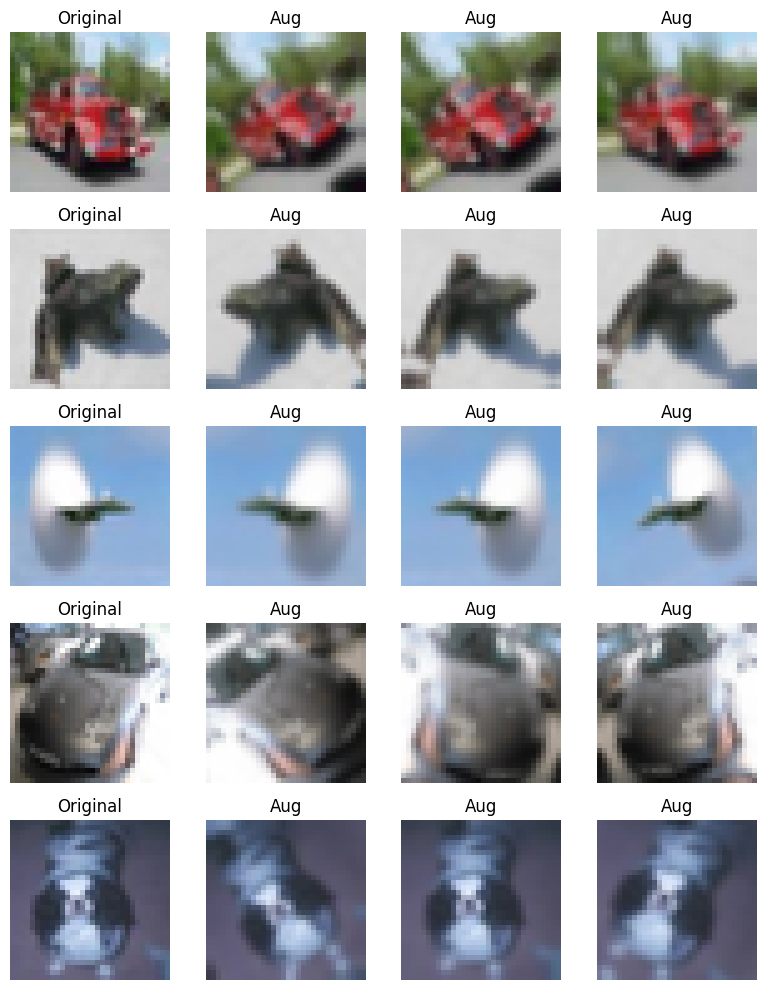

In [12]:
# PROBLEM 4

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

plt.figure(figsize=(8,10))

for i in range(5):
    idx = np.random.randint(0, len(x_train))
    img = x_train[idx]

    plt.subplot(5,4,i*4+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    for j in range(3):
        aug_img = data_aug(tf.expand_dims(img, 0))[0].numpy().astype("uint8")
        plt.subplot(5,4,i*4+2+j)
        plt.imshow(aug_img)
        plt.title("Aug")
        plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()